In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The intraday data was downloaded ONCE from the Polygon API. If any parameter changes, please uncomment the following cell. The data was saved to data/raw/INTC_1min_mar_sep_2026.csv.

In [19]:
# Original download code (requires your own API key in the
# POLYGON_API_KEY environment variable), kept here for reference:
# import os
# from polygon import RESTClient
# client = RESTClient(os.environ["POLYGON_API_KEY"])
# def download_intraday(ticker, start, end, interval="1", time_unit='minute'):
#     aggs = []
#     for a in client.list_aggs(
#         ticker,
#         interval,
#         time_unit,
#         start,
#         end,
#         limit=50000,
#     ):
#         aggs.append(a)
#     return aggs
# # chunks = download_intraday('INTC', '2026-03-01', '2026-09-01', 1, 'minute')
# chunks[0]

Again, if you are downloading the data for the first time, the next cell must be run; otherwise continue.

In [20]:
# chunks[0]
# Stock = pd.DataFrame([
#     {
#         'Open': x.open,
#         'High': x.high,
#         'Low': x.low,
#         'Close': x.close,
#         'Volume': x.volume,
#         'Timestamp': x.timestamp
#     }
#     for x in chunks
# ])

# Stock['Timestamp'] = pd.to_datetime( Stock['Timestamp'],unit='ms',utc=True
# )
# Stock = Stock.set_index('Timestamp')
# Stock.index = Stock.index.tz_convert('America/New_York')
# Stock.head()
# Stock.index.min(), Stock.index.max()
# Stock.to_csv('../data/raw/INTC_1min_mar_sep_2026.csv')

In [21]:
Stock = pd.read_csv(
    '../data/raw/INTC_1min_mar_sep_2026.csv',
    index_col='Timestamp',
    parse_dates=True,
)
Stock.index = pd.to_datetime(Stock.index, utc=True).tz_convert('America/New_York')
Stock.head(3)

,Open,High,Low,Close,Volume
Timestamp,,,,,
2026-03-02 04:00:00-05:00,44.00,44.48,43.99,44.03,16758.0
2026-03-02 04:01:00-05:00,44.05,44.09,43.90,43.92,21608.0
2026-03-02 04:02:00-05:00,43.92,43.96,43.92,43.96,1815.0


In [22]:
Data=Stock.between_time('10:00','11:00')
Data['date_5min']=Data.index.floor('5min')
Data['date']=Data.index.date
movement_5min=Data.groupby(by=['date','date_5min']).apply(lambda x:x['Open'].iloc[0] - x['Close'].iloc[-1])
movement_5min = movement_5min.rename('movement_5min')
movement_5min = movement_5min.reset_index()
movement_5min.columns
Data

/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_33823/2063095343.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['date_5min']=Data.index.floor('5min')
/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_33823/2063095343.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['date']=Data.index.date
/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_33823/2063095343.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecat

,Open,High,Low,Close,Volume,date_5min,date
Timestamp,,,,,,,
2026-03-02 10:00:00-05:00,44.9100,44.9400,44.630,44.655,364711.286300,2026-03-02 10:00:00-05:00,2026-03-02
2026-03-02 10:01:00-05:00,44.6600,44.8200,44.660,44.820,199803.101151,2026-03-02 10:00:00-05:00,2026-03-02
2026-03-02 10:02:00-05:00,44.8200,44.9200,44.790,44.840,257474.671109,2026-03-02 10:00:00-05:00,2026-03-02
2026-03-02 10:03:00-05:00,44.8400,44.8500,44.700,44.765,128600.897694,2026-03-02 10:00:00-05:00,2026-03-02
2026-03-02 10:04:00-05:00,44.7700,44.8400,44.650,44.800,167080.684007,2026-03-02 10:00:00-05:00,2026-03-02
...,...,...,...,...,...,...,...
2026-09-01 10:56:00-04:00,88.0801,88.2200,88.070,88.215,243610.827635,2026-09-01 10:55:00-04:00,2026-09-01
2026-09-01 10:57:00-04:00,88.2250,88.3400,88.155,88.250,723091.837785,2026-09-01 10:55:00-04:00,2026-09-01
2026-09-01 10:58:00-04:00,88.2600,88.4885,88.245,88.450,261272.113443,2026-09-01 10:55:00-04:00,2026-09-01


Text(0, 0.5, 'Number of intervals')

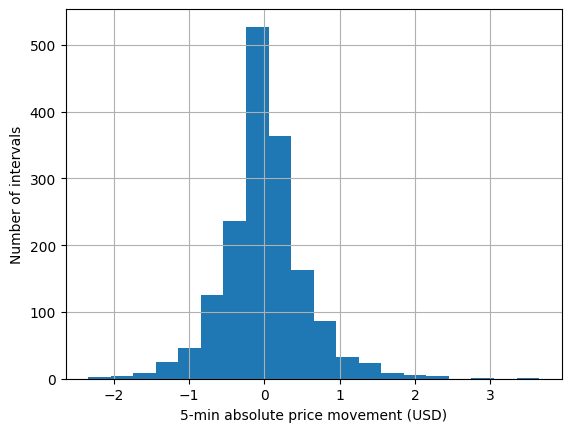

In [23]:
movement_5min['movement_5min'].hist(bins=20)
plt.xlabel('5-min absolute price movement (USD)')
plt.ylabel('Number of intervals')

(array([20513.20833333, 20544.16666667, 20574.16666667, 20605.16666667,
        20635.16666667, 20666.16666667, 20697.16666667]),
 [Text(20513.208333333332, 0, '2026-03'),
  Text(20544.166666666668, 0, '2026-04'),
  Text(20574.166666666668, 0, '2026-05'),
  Text(20605.166666666668, 0, '2026-06'),
  Text(20635.166666666668, 0, '2026-07'),
  Text(20666.166666666668, 0, '2026-08'),
  Text(20697.166666666668, 0, '2026-09')])

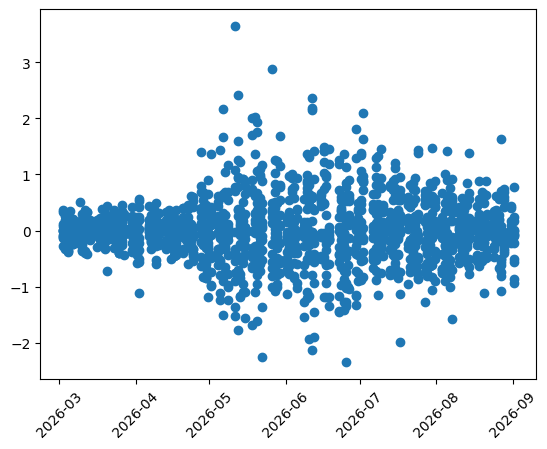

In [24]:
plt.scatter(movement_5min['date_5min'],movement_5min['movement_5min'])
plt.xticks(rotation=45)
# movement_5min['date_5min']

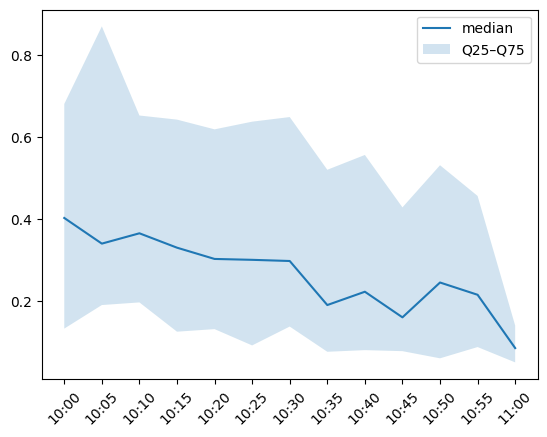

In [25]:
movement_5min['time'] = movement_5min['date_5min'].dt.strftime('%H:%M')
up=movement_5min[movement_5min['movement_5min']>0]
stats_up = up.groupby('time')['movement_5min'].agg(
    mean='mean',
    median='median',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    count='count'
)
plt.plot(stats_up.index, stats_up['median'], label='median')

plt.fill_between(
    stats_up.index,
    stats_up['q25'],
    stats_up['q75'],
    alpha=0.2,
    label='Q25–Q75'
)
plt.xticks(rotation=45)
plt.legend()

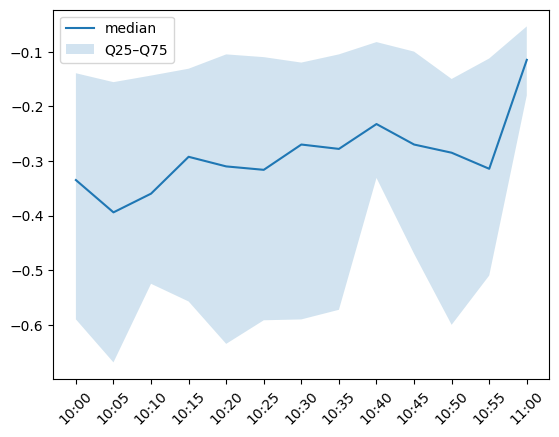

In [26]:
movement_5min['time'] = movement_5min['date_5min'].dt.strftime('%H:%M')
down=movement_5min[movement_5min['movement_5min']<0]
stats_down = down.groupby('time')['movement_5min'].agg(
    mean='mean',
    median='median',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    count='count'
)
plt.plot(stats_down.index, stats_down['median'], label='median')

plt.fill_between(
    stats_down.index,
    stats_down['q25'],
    stats_down['q75'],
    alpha=0.2,
    label='Q25–Q75'
)
plt.xticks(rotation=45)
plt.legend()

In [27]:
stats_up

,mean,median,std,q25,q75,count
time,,,,,,
10:00,0.513054,0.40250,0.536602,0.132500,0.680675,56
10:05,0.529170,0.33990,0.479792,0.190000,0.870000,61
10:10,0.477630,0.36510,0.390146,0.196450,0.652500,63
10:15,0.474332,0.33000,0.480759,0.125000,0.642500,74
10:20,0.403237,0.30250,0.340174,0.131250,0.618750,62
10:25,0.521176,0.30035,0.667427,0.091475,0.637475,58
10:30,0.444468,0.29750,0.439814,0.137500,0.648750,62
10:35,0.352574,0.19000,0.369243,0.076000,0.520100,61
10:40,0.355784,0.22250,0.348255,0.079975,0.556250,68


In [28]:
TOTAL=stats_up.merge(stats_down,on='time',suffixes=['_up','_down'])
TOTAL['probability_up']=TOTAL['count_up']/(TOTAL['count_up']+TOTAL['count_down'])
TOTAL=TOTAL.reset_index()

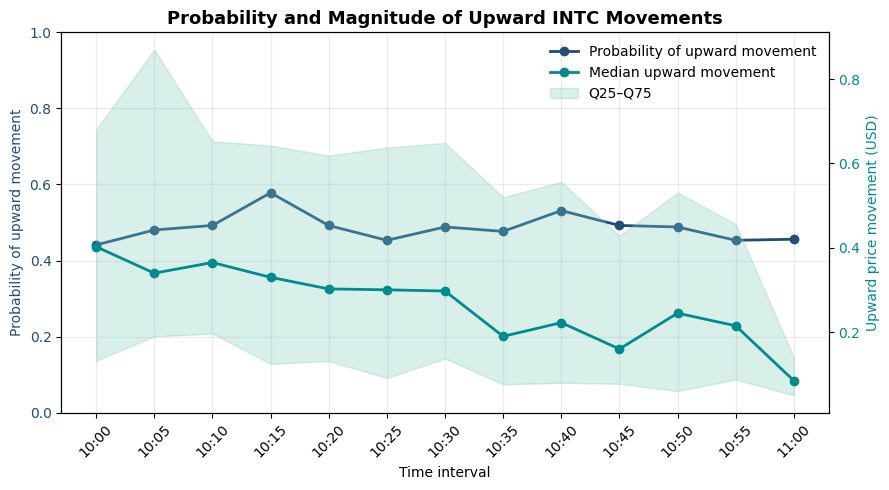

In [29]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# Probability of upward movement
ax1.plot(
    TOTAL['time'],
    TOTAL['probability_up'],
    marker='o',
    color='#1f4e79',
    linewidth=2,
    label='Probability of upward movement'
)

ax1.set_ylabel(
    'Probability of upward movement',
    color='#1f4e79'
)
ax1.tick_params(axis='y', labelcolor='#1f4e79')
ax1.set_ylim(0, 1)
ax1.set_xlabel('Time interval')

# Median upward movement
ax2 = ax1.twinx()

ax2.plot(
    TOTAL['time'],
    TOTAL['median_up'],
    marker='o',
    color='#008c8c',
    linewidth=2,
    label='Median upward movement'
)

# Interquartile range
ax2.fill_between(
    TOTAL['time'],
    TOTAL['q25_up'],
    TOTAL['q75_up'],
    color='#7fcdbb',
    alpha=0.30,
    label='Q25–Q75'
)

ax2.set_ylabel(
    'Upward price movement (USD)',
    color='#008c8c'
)
ax2.tick_params(axis='y', labelcolor='#008c8c')

ax1.tick_params(axis='x', rotation=45)

ax1.set_title(
    'Probability and Magnitude of Upward INTC Movements',
    fontsize=13,
    fontweight='bold'
)

ax1.grid(alpha=0.25)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right',
    frameon=False
)

plt.tight_layout()

Increasing the historical sample from one month to six months substantially reduced the apparent edge observed in the initial analysis, highlighting the importance of robustness checks before defining a trading rule.

#### Backtesting: Based on the probability of an upward movement, let's backtest a hypothesis: The time interval with most probability of an upward movement correspond to the time with most probability of an earning.

In [30]:
# Let's add the expected value of the median, that we'll define as:
# EV=P(up)×MedianUp−(1−P(up))×MedianDown
TOTAL['EV']=TOTAL['probability_up']*TOTAL['median_up']-(1-TOTAL['probability_up'])*TOTAL['median_down']
TOTAL

,time,mean_up,median_up,std_up,q25_up,q75_up,count_up,mean_down,median_down,std_down,q25_down,q75_down,count_down,probability_up,EV
0,10:00,0.513054,0.40250,0.536602,0.132500,0.680675,56,-0.437838,-0.33500,0.418394,-0.590000,-0.139500,71,0.440945,0.364764
1,10:05,0.529170,0.33990,0.479792,0.190000,0.870000,61,-0.518295,-0.39415,0.491708,-0.668750,-0.155800,66,0.480315,0.368093
2,10:10,0.477630,0.36510,0.390146,0.196450,0.652500,63,-0.429372,-0.35990,0.388592,-0.524900,-0.143800,65,0.492188,0.362459
3,10:15,0.474332,0.33000,0.480759,0.125000,0.642500,74,-0.382367,-0.29245,0.315284,-0.557250,-0.131250,54,0.578125,0.314159
4,10:20,0.403237,0.30250,0.340174,0.131250,0.618750,62,-0.405625,-0.31005,0.359158,-0.634875,-0.105000,64,0.492063,0.306335
5,10:25,0.521176,0.30035,0.667427,0.091475,0.637475,58,-0.409000,-0.31630,0.369695,-0.591675,-0.110025,70,0.453125,0.309073
6,10:30,0.444468,0.29750,0.439814,0.137500,0.648750,62,-0.440332,-0.27000,0.437225,-0.590100,-0.120000,65,0.488189,0.283425
7,10:35,0.352574,0.19000,0.369243,0.076000,0.520100,61,-0.396707,-0.27800,0.376158,-0.572500,-0.105000,67,0.476562,0.236063
8,10:40,0.355784,0.22250,0.348255,0.079975,0.556250,68,-0.267243,-0.23250,0.234137,-0.331175,-0.082500,60,0.531250,0.227187
9,10:45,0.320560,0.16000,0.347308,0.077500,0.428350,63,-0.325791,-0.27000,0.280162,-0.469900,-0.099900,65,0.492188,0.215859


In [31]:
#Now, we calculate:
#MFE = max High − entry price.
#MAE = entry price − min Low
#We're gonna do from 10:00 to 10:15
Data_bt=Data.between_time('10:00','10:15')
Low=Data_bt.groupby(['date'])['Low'].agg('min')
High=Data_bt.groupby(['date'])['High'].agg('max')
entry = Data_bt.groupby('date')['Open'].agg('first')
close = Data_bt.groupby('date')['Close'].agg('last')
Data_bt_stats=pd.concat([High,Low,entry,close],axis=1)
Data_bt_stats['MAE']=Data_bt_stats['Open']-Data_bt_stats['Low']
Data_bt_stats['MFE']=Data_bt_stats['High']-Data_bt_stats['Open']
Data_bt_stats

,High,Low,Open,Close,MAE,MFE
date,,,,,,
2026-03-02,45.040,44.625,44.910,44.6850,0.285,0.130
2026-03-03,43.270,42.660,42.755,42.8600,0.095,0.515
2026-03-04,43.995,43.390,43.390,43.7791,0.000,0.605
2026-03-05,46.480,45.960,46.055,46.3378,0.095,0.425
2026-03-06,45.030,44.585,44.650,44.7802,0.065,0.380
...,...,...,...,...,...,...
2026-08-26,87.210,86.090,87.210,86.1200,1.120,0.000
2026-08-27,90.970,88.785,88.785,90.8338,0.000,2.185
2026-08-28,93.515,91.050,93.110,91.3800,2.060,0.405


This dataframe :Data_bt_stats will allow us to backtest our hypothesis. As we saw  in the plot of probability we have that the expected median from 10:00 to 10:15 was about 0.36 in six months, so we are gonna put a TP at Open+0.3 and a SL at Open-0.6


--- MAE ANALYSIS FOR TP = 0.36 ---
To avoid choking your winning trades, your SL should be at least:
To keep 80% of winning trades: SL = 1.209
To keep 90% of winning trades: SL = 1.819
To keep 95% of winning trades: SL = 2.294 (Recommended)
The largest drawdown suffered by a winning trade was: 3.940


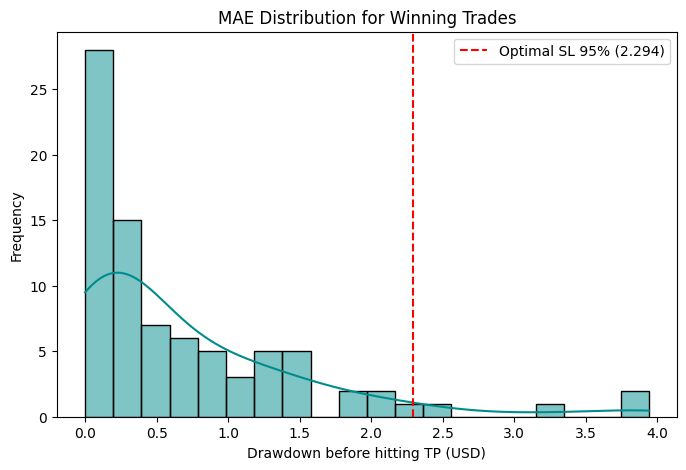

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the target TP based on the previous analysis (statistical median)
target_tp = 0.36

# 2. Isolate the trades that would have been winners (MFE exceeds the TP)
winning_trades = Data_bt_stats[Data_bt_stats['MFE'] >= target_tp]

# 3. Analyze the MAE of these winning trades only
mae_winners = winning_trades['MAE']

# 4. Compute percentiles to define the Stop Loss
sl_optimal_80 = mae_winners.quantile(0.80)
sl_optimal_90 = mae_winners.quantile(0.90)
sl_optimal_95 = mae_winners.quantile(0.95)
sl_max = mae_winners.max()

print(f"--- MAE ANALYSIS FOR TP = {target_tp} ---")
print("To avoid choking your winning trades, your SL should be at least:")
print(f"To keep 80% of winning trades: SL = {sl_optimal_80:.3f}")
print(f"To keep 90% of winning trades: SL = {sl_optimal_90:.3f}")
print(f"To keep 95% of winning trades: SL = {sl_optimal_95:.3f} (Recommended)")
print(f"The largest drawdown suffered by a winning trade was: {sl_max:.3f}")

# 5. Visualize the "noise" before winning
plt.figure(figsize=(8, 5))
sns.histplot(mae_winners, bins=20, kde=True, color='#008c8c')
plt.axvline(sl_optimal_95, color='red', linestyle='--', label=f'Optimal SL 95% ({sl_optimal_95:.3f})')
plt.title('MAE Distribution for Winning Trades')
plt.xlabel('Drawdown before hitting TP (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [39]:
#So As we already have our MAE and MFE, we just have to classify them  when we obtained MAE<SL and when MFE>TP
TP=0.36
SL=2.4
Initial_capital=10000 #USD
Data_bt_stats['Result'] = np.where(
    Data_bt_stats['MAE'] > SL, 'Loss', 
    np.where(Data_bt_stats['MFE'] > TP, 'Win', 'None')
)
Data_bt_stats['PnL'] = np.select([Data_bt_stats['Result']=='Win',Data_bt_stats['Result']=='Loss',Data_bt_stats['Result']=='None'],[TP * Initial_capital/Data_bt_stats['Open'], -SL * Initial_capital/Data_bt_stats['Open'], Initial_capital/Data_bt_stats['Open']*(Data_bt_stats['Open']-Data_bt_stats['Close'])],default=0.0)
total_wins=Data_bt_stats[Data_bt_stats['Result']=='Win']['PnL'].sum()
total_losses = Data_bt_stats[Data_bt_stats['Result']=='Loss']['PnL'].sum()
total_none   = Data_bt_stats[Data_bt_stats['Result']=='None']['PnL'].sum()
print(total_wins,total_losses,total_def,total_wins+total_losses+total_def)
# Data_bt_stats
Data_bt_stats['PnL'].mean()

3362.645854483376 -818.5954598373486 0.0 2544.050394646027


np.float64(40.21424545002121)